## Generate ECG Signals for Arrhythmia Classes using NeuroKit2

In [ ]:
# Install neurokit2 if not already installed
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 36.8 MB/s eta 0:00:00


In [ ]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define parameters
sampling_rate = 250 # Hz
duration = 5     # seconds for each signal
heart_rates = [40, 90, 120] # bpm for the three classes
num_signals_per_class = 50 # Number of signals to generate for each class

ecg_database = []

for hr in heart_rates:
    print(f"Generating ECG signals for {hr} BPM...")
    for i in range(num_signals_per_class):
        # Simulate an ECG signal with the specified heart rate
        ecg_signal = nk.ecg_simulate(duration=duration, sampling_rate=sampling_rate, heart_rate=hr, noise=0.05)

        # Create a dictionary to store the signal and its metadata
        signal_data = {
            'heart_rate_bpm': hr,
            'class_label': f'{hr}bpm',
            'ecg_signal': ecg_signal
        }
        ecg_database.append(signal_data)

# Convert the list of dictionaries to a pandas DataFrame for easier handling
df_ecg = pd.DataFrame(ecg_database)

print(f"\nGenerated {len(df_ecg)} ECG signals.")
display(df_ecg.head())

Generating ECG signals for 40 BPM...
Generating ECG signals for 90 BPM...
Generating ECG signals for 120 BPM...

Generated 150 ECG signals.


,heart_rate_bpm,class_label,ecg_signal
0,40,40bpm,"[1.0690822688014023, 1.0364104068509874, 0.950..."
1,40,40bpm,"[1.0530027440144627, 1.0201921488548695, 0.933..."
2,40,40bpm,"[1.0564640181845615, 1.0249154313111535, 0.941..."
3,40,40bpm,"[1.0525034039048833, 1.0195768953630178, 0.932..."
4,40,40bpm,"[1.0587678334096404, 1.0262559304370822, 0.940..."


### Visualize a Sample ECG Signal

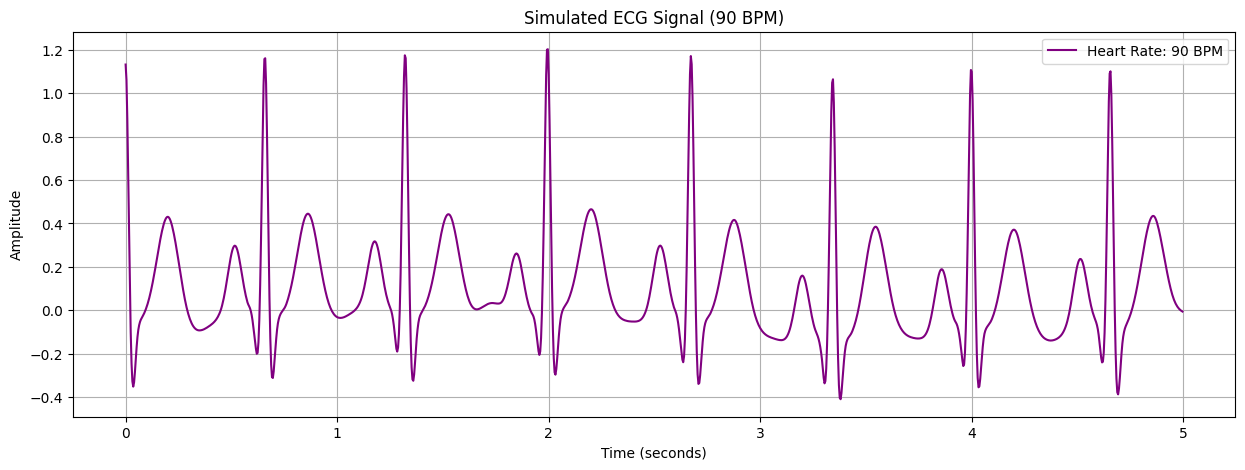

In [ ]:
#@title { vertical-output: true}

# Select one signal to visualize (e.g., the first 90bpm signal)
sample_signal_data = df_ecg[df_ecg['class_label'] == '90bpm'].iloc[0]
sample_signal = sample_signal_data['ecg_signal']
sample_hr = sample_signal_data['heart_rate_bpm']

# Create a time vector
time = np.arange(len(sample_signal)) / sampling_rate

plt.figure(figsize=(15, 5))
plt.plot(time, sample_signal, color='purple', label=f'Heart Rate: {sample_hr} BPM')
plt.title(f'Simulated ECG Signal ({sample_hr} BPM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

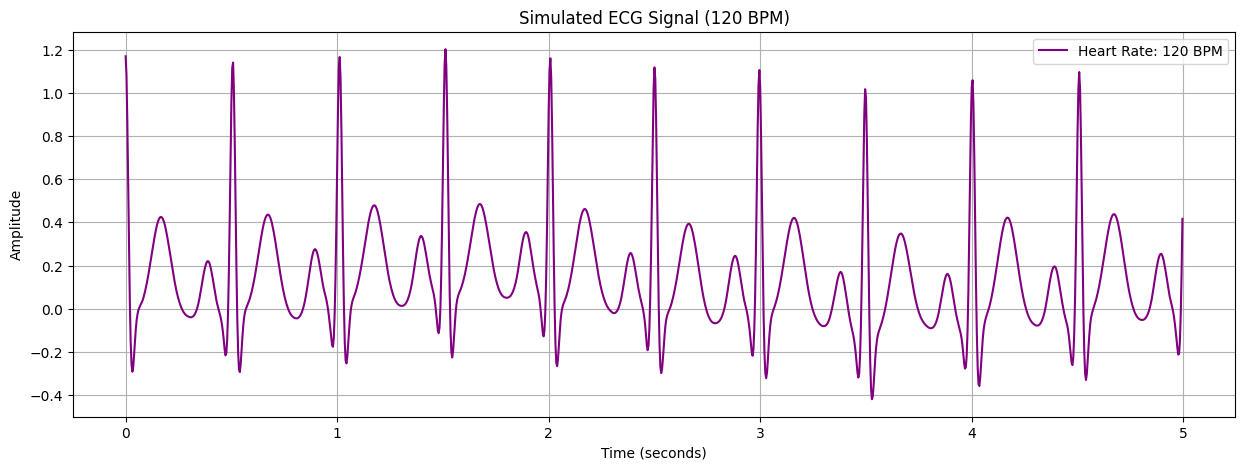

In [ ]:
#@title { vertical-output: true}

# Select one signal to visualize (e.g., the first 90bpm signal)
sample_signal_data = df_ecg[df_ecg['class_label'] == '120bpm'].iloc[0]
sample_signal = sample_signal_data['ecg_signal']
sample_hr = sample_signal_data['heart_rate_bpm']

# Create a time vector
time = np.arange(len(sample_signal)) / sampling_rate

plt.figure(figsize=(15, 5))
plt.plot(time, sample_signal, color='purple', label=f'Heart Rate: {sample_hr} BPM')
plt.title(f'Simulated ECG Signal ({sample_hr} BPM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

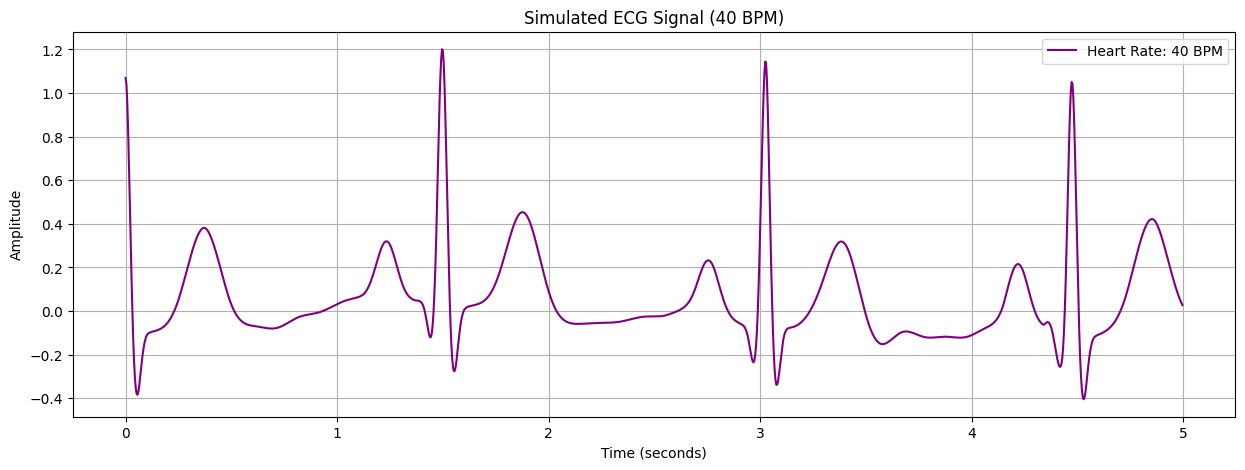

In [ ]:
#@title { vertical-output: true}

# Select one signal to visualize (e.g., the first 90bpm signal)
sample_signal_data = df_ecg[df_ecg['class_label'] == '40bpm'].iloc[0]
sample_signal = sample_signal_data['ecg_signal']
sample_hr = sample_signal_data['heart_rate_bpm']

# Create a time vector
time = np.arange(len(sample_signal)) / sampling_rate

plt.figure(figsize=(15, 5))
plt.plot(time, sample_signal, color='purple', label=f'Heart Rate: {sample_hr} BPM')
plt.title(f'Simulated ECG Signal ({sample_hr} BPM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
df_ecg.head()

,heart_rate_bpm,class_label,ecg_signal
0,40,40bpm,"[1.0690822688014023, 1.0364104068509874, 0.950..."
1,40,40bpm,"[1.0530027440144627, 1.0201921488548695, 0.933..."
2,40,40bpm,"[1.0564640181845615, 1.0249154313111535, 0.941..."
3,40,40bpm,"[1.0525034039048833, 1.0195768953630178, 0.932..."
4,40,40bpm,"[1.0587678334096404, 1.0262559304370822, 0.940..."


In [ ]:
df_ecg.groupby("class_label").size()

,0
class_label,
120bpm,50
40bpm,50
90bpm,50


<Axes: ylabel='class_label'>

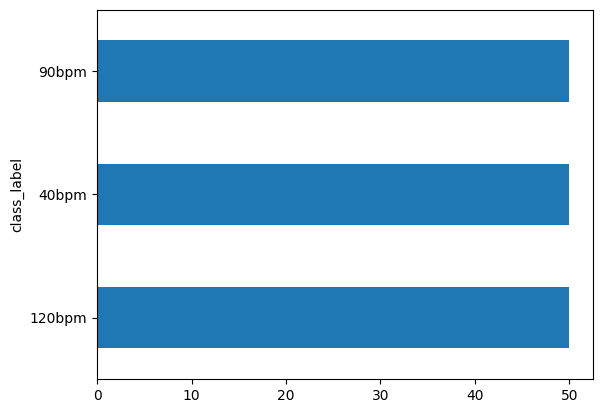

In [ ]:
df_ecg.groupby("class_label").size().plot(kind="barh")

In [ ]:
df_ecg.to_csv("ecg_database.csv", index=False)

# CHALLENGE

Apartir del dataset sintético de arritmias, extraer caracterśticas relevantes de las clases y crear un modelo clasificador tanto en tensorflow como en arduino usando raspberry pi pico.

Se recomienda usar 3 características relevantes o un PCA de 3 componentes. Deben exportar el firmware a wokwi y probar con 3 potenciometros.

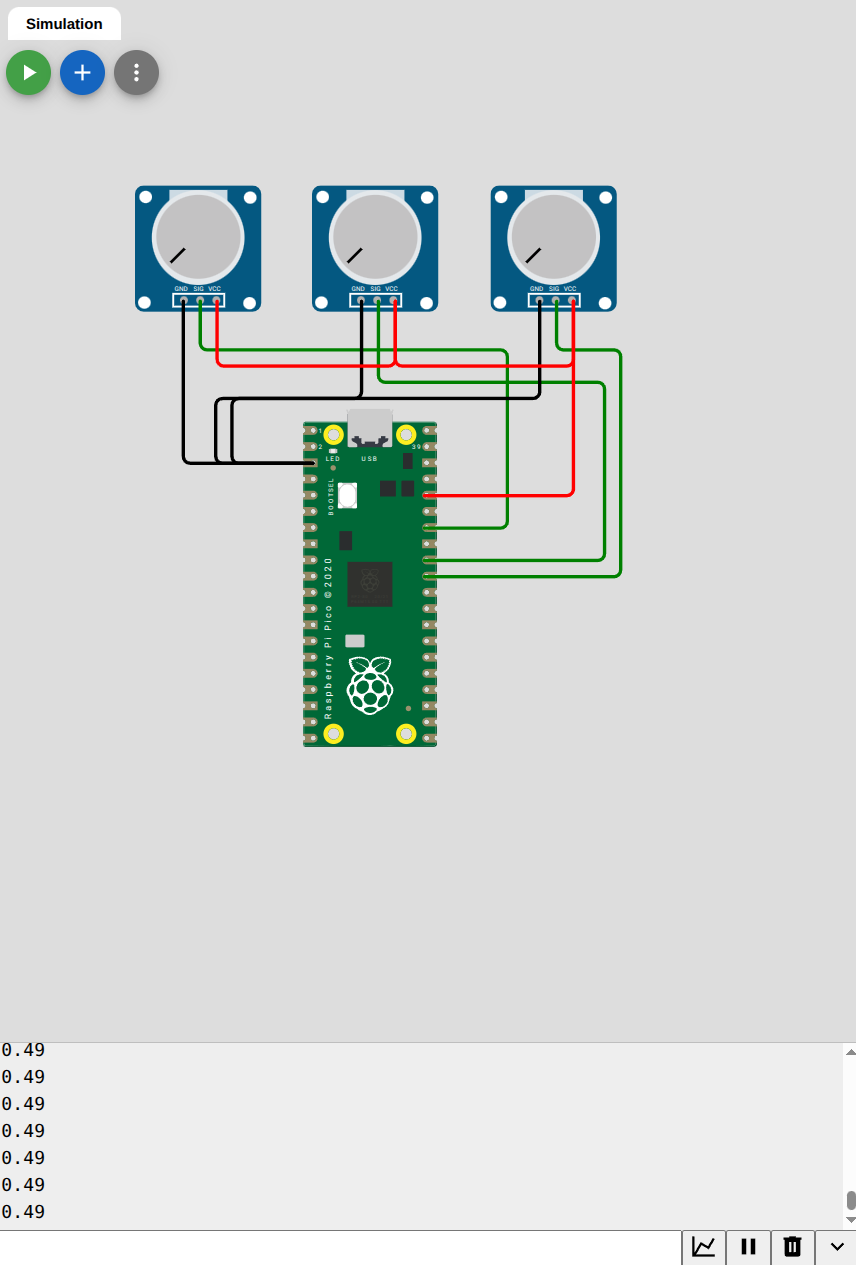